## Setup and Data Loading

In [16]:
# Import required libraries
import os
from pathlib import Path

# Ensure Matplotlib can write its cache/config inside the repo
os.environ.setdefault('MPLCONFIGDIR', str((Path('..') / '.mplconfig').resolve()))

import matplotlib
# Work around matplotlib_inline expecting a private rcParams._get attribute
if not hasattr(matplotlib.rcParams, '_get'):
    matplotlib.rcParams._get = matplotlib.rcParams.get  # type: ignore[attr-defined]

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm
from collections import defaultdict, Counter
import warnings
warnings.filterwarnings('ignore')

# Import trajdata
from trajdata import UnifiedDataset, AgentType

# Set plotting style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10

print("✓ Libraries loaded successfully")


✓ Libraries loaded successfully


In [17]:
# Configure data path
NUSCENES_ROOT = Path('../data/raw').resolve()
if not NUSCENES_ROOT.exists():
    raise FileNotFoundError(f"nuScenes root not found at {NUSCENES_ROOT}")

print(f"Data directory: {NUSCENES_ROOT}")

Data directory: /Users/simondrauz/Lokale Dokumente/Repositories/ds_practical/data/raw


In [ ]:
# Define map parameters
map_params = {
    "px_per_m": 2,
    "map_size_px": 224,
}

# Load dataset with trajdata
# Additional Context: This call determines what type of trajectories are included in the data subtset (e.g. agent-centric vs scene-centric, history/future lengths, map inclusion, etc.)
dataset = UnifiedDataset(
    desired_data=["nusc_mini"],
    centric="agent",
    desired_dt=0.1,
    history_sec=(3.2, 3.2),  # 3.2 seconds history
    future_sec=(4.8, 4.8),   # 4.8 seconds future
    incl_raster_map=True,
    raster_map_params=map_params,
    incl_vector_map=True,
    incl_robot_future=True,  # Include robot future for ego-agent distance
    max_neighbor_num=None,  # Include all neighbors (no cap) to see true density
    verbose=True,
    data_dirs={"nusc_mini": str(NUSCENES_ROOT)},
    num_workers=0,
)

print(f"\n✓ Dataset loaded: {len(dataset)} agent trajectories")

Loading data for matched scene tags: ['nusc_mini-mini_train-boston', 'nusc_mini-singapore-mini_train', 'nusc_mini-boston-mini_val', 'nusc_mini-singapore-mini_val']


Calculating Agent Data (Serially): 100%|██████████| 10/10 [00:00<00:00, 37052.16it/s]


10 scenes in the scene index.


Structuring Agent Data Index: 100%|██████████| 10/10 [00:00<00:00, 13609.03it/s]


✓ Dataset loaded: 25197 agent trajectories


## Step 1: Dataset Characteristics

### 1.1 Agent Population Analysis

In [33]:
# Extract agent information from dataset
print("Collecting agent population data...")

agent_types = []
agent_names = set()

# Sample subset for faster analysis (adjust sample_size for full analysis)
sample_size = min(5000, len(dataset))
indices = np.random.choice(len(dataset), sample_size, replace=False)

for idx in tqdm(indices, desc="Analyzing agents"):
    batch = dataset[idx]
    agent_types.append(batch.agent_type.name)
    agent_names.add(batch.agent_name)

print(f"\nTotal unique agents (in sample): {len(agent_names)}")
print(f"Total trajectories analyzed: {len(agent_types)}")

Analyzing agents: 100%|██████████| 5000/5000 [01:14<00:00, 67.40it/s]


Total unique agents (in sample): 407
Total trajectories analyzed: 5000


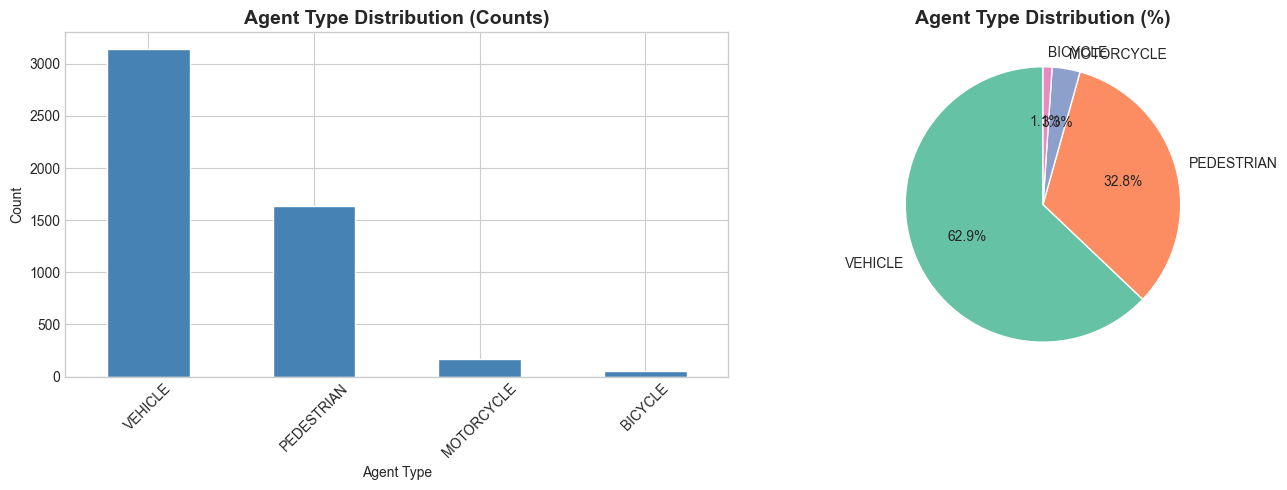


📊 Agent Type Summary:
VEHICLE        :  3145 ( 62.9%)
PEDESTRIAN     :  1638 ( 32.8%)
MOTORCYCLE     :   164 (  3.3%)
BICYCLE        :    53 (  1.1%)


In [5]:
# Agent Type Distribution
agent_type_counts = pd.Series(agent_types).value_counts()
agent_type_pct = agent_type_counts / agent_type_counts.sum() * 100

# Create visualization
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart
agent_type_counts.plot(kind='bar', ax=ax1, color='steelblue')
ax1.set_title('Agent Type Distribution (Counts)', fontsize=14, fontweight='bold')
ax1.set_xlabel('Agent Type')
ax1.set_ylabel('Count')
ax1.tick_params(axis='x', rotation=45)

# Pie chart
colors = sns.color_palette('Set2', len(agent_type_pct))
ax2.pie(agent_type_pct, labels=agent_type_pct.index, autopct='%1.1f%%', 
        colors=colors, startangle=90)
ax2.set_title('Agent Type Distribution (%)', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('../results/evaluation/plots/characterization/agent_type_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

# Print summary
print("\n📊 Agent Type Summary:")
print("=" * 50)
for agent_type, count in agent_type_counts.items():
    pct = agent_type_pct[agent_type]
    print(f"{agent_type:15s}: {count:5d} ({pct:5.1f}%)")

### 1.2 Scene Characteristics

Analyze agent density, observation duration, and ego-agent distances.

In [ ]:
# Collect scene-level statistics
print("Collecting scene characteristics...")

# Calculate map area using the defined map_params
map_side_m = map_params["map_size_px"] / map_params["px_per_m"]
map_area_m2 = map_side_m ** 2

print(f"Map area: {map_area_m2:.2f} m²")

scene_data = {
    'num_neighbors': [],
    'agent_density_m2': [],
    'ego_distance': [],
    'scene_id': [],
}

ego_data_count = 0

for idx in tqdm(indices, desc="Analyzing scenes"):
    batch = dataset[idx]
    
    # Agent density: count neighbors
    n_neighbors = 0
    if hasattr(batch, 'num_neighbors'):
        n_neighbors = batch.num_neighbors
    elif hasattr(batch, 'neighbor_histories') and batch.neighbor_histories is not None:
        n_neighbors = len(batch.neighbor_histories)
    
    scene_data['num_neighbors'].append(n_neighbors)
    scene_data['agent_density_m2'].append(n_neighbors / map_area_m2)
    
    # Ego-agent distance
    # We use robot_future_np[0] which corresponds to the current time step (t=0)
    # when incl_robot_future=True is set in UnifiedDataset.
    distance = np.nan
    if hasattr(batch, 'robot_future_np') and batch.robot_future_np is not None:
        if len(batch.robot_future_np) > 0:
            ego_pos = batch.robot_future_np[0, :2]
            # In agent-centric mode, the agent is at (0,0) at t=0
            # We can verify this or just use the robot position directly as the relative distance
            # But to be consistent with the data:
            agent_pos = batch.agent_history_np[-1, :2] 
            distance = np.linalg.norm(ego_pos - agent_pos)
            ego_data_count += 1
            
    scene_data['ego_distance'].append(distance)
    scene_data['scene_id'].append(batch.scene_ts)

scene_df = pd.DataFrame(scene_data)
print(f"\n✓ Analyzed {len(scene_df)} scenes")
print(f"✓ Ego data available for {ego_data_count} scenes")

Map area: 12544.00 m²


Analyzing scenes: 100%|██████████| 5000/5000 [01:11<00:00, 70.10it/s]


✓ Analyzed 5000 scenes
✓ Ego data available for 5000 scenes


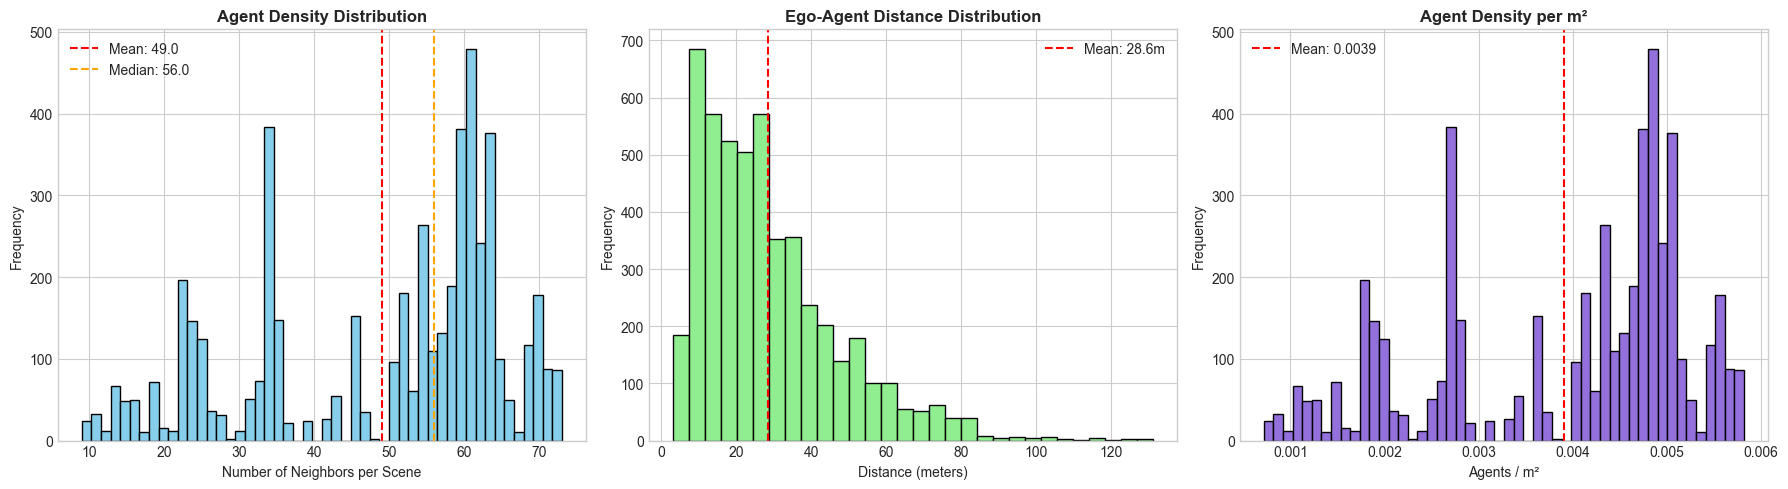


📊 Scene Characteristics Summary:
       num_neighbors  agent_density_m2  ego_distance
count      5000.0000         5000.0000     5000.0000
mean         49.0362            0.0039       28.5723
std          16.8541            0.0013       18.4886
min           9.0000            0.0007        3.0317
25%          34.0000            0.0027       14.4356
50%          56.0000            0.0045       24.5943
75%          61.0000            0.0049       37.2538
max          73.0000            0.0058      131.3168

Scenes with 0 neighbors: 0 (0.0%)


In [37]:
# Visualize scene characteristics
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Agent Density (number of neighbors)
ax = axes[0]
scene_df['num_neighbors'].hist(bins=50, ax=ax, color='skyblue', edgecolor='black')
ax.set_title('Agent Density Distribution', fontsize=12, fontweight='bold')
ax.set_xlabel('Number of Neighbors per Scene')
ax.set_ylabel('Frequency')
ax.axvline(scene_df['num_neighbors'].mean(), color='red', linestyle='--', 
           label=f'Mean: {scene_df["num_neighbors"].mean():.1f}')
ax.axvline(scene_df['num_neighbors'].median(), color='orange', linestyle='--',
           label=f'Median: {scene_df["num_neighbors"].median():.1f}')
ax.legend()

# Ego-Agent Distance
ax = axes[1]
ego_dist = scene_df['ego_distance'].dropna()
if len(ego_dist) > 0:
    ego_dist.hist(bins=30, ax=ax, color='lightgreen', edgecolor='black')
    ax.set_title('Ego-Agent Distance Distribution', fontsize=12, fontweight='bold')
    ax.set_xlabel('Distance (meters)')
    ax.set_ylabel('Frequency')
    ax.axvline(ego_dist.mean(), color='red', linestyle='--',
               label=f'Mean: {ego_dist.mean():.1f}m')
    ax.legend()
else:
    ax.text(0.5, 0.5, 'Ego data not available', ha='center', va='center', transform=ax.transAxes)
    ax.set_title('Ego-Agent Distance Distribution', fontsize=12, fontweight='bold')

# Agent Density per m2
ax = axes[2]
scene_df['agent_density_m2'].hist(bins=50, ax=ax, color='mediumpurple', edgecolor='black')
ax.set_title('Agent Density per m²', fontsize=12, fontweight='bold')
ax.set_xlabel('Agents / m²')
ax.set_ylabel('Frequency')
mean_density = scene_df['agent_density_m2'].mean()
ax.axvline(mean_density, color='red', linestyle='--', 
           label=f'Mean: {mean_density:.4f}')
ax.legend()

plt.tight_layout()
plt.savefig('../results/evaluation/plots/characterization/scene_characteristics.png', dpi=300, bbox_inches='tight')
plt.show()

# Print statistics
print("\n📊 Scene Characteristics Summary:")
print("=" * 50)

# Use pandas describe() for a cleaner, standardized statistical summary
stats = scene_df[['num_neighbors', 'agent_density_m2', 'ego_distance']].describe().round(4)
print(stats)

# Calculate specific zero-neighbor stat manually as it's not in describe()
zero_neighbors = (scene_df['num_neighbors'] == 0).sum()
print(f"\nScenes with 0 neighbors: {zero_neighbors} ({zero_neighbors/len(scene_df)*100:.1f}%)")

### 1.3 Motion Dynamics

Analyze speed, acceleration, jerk, and trajectory nonlinearity.

In [15]:
# Collect motion dynamics
print("Collecting motion dynamics...")

motion_data = {
    'speed': [],
    'acceleration': [],
    'jerk': [],
    'heading_change': [],
    'path_efficiency': [],
    'is_stationary': [],
}

dt = 0.1  # timestep

for idx in tqdm(indices, desc="Analyzing motion"):
    batch = dataset[idx]
    history = batch.agent_history_np
    
    # Remove NaN values
    valid_mask = ~np.isnan(history).any(axis=1)
    if valid_mask.sum() < 3:  # Need at least 3 points
        continue
    
    positions = history[valid_mask, :2]  # x, y coordinates
    
    # Calculate velocities
    velocities = np.diff(positions, axis=0) / dt
    speeds = np.linalg.norm(velocities, axis=1)
    
    # Mean speed
    mean_speed = speeds.mean()
    motion_data['speed'].append(mean_speed)
    
    # Stationary check (speed < 0.2 m/s for more strict threshold)
    motion_data['is_stationary'].append(mean_speed < 0.2)
    
    # Acceleration
    if len(speeds) > 1:
        accelerations = np.diff(speeds) / dt
        motion_data['acceleration'].append(np.abs(accelerations).mean())
        
        # Jerk (rate of change of acceleration)
        if len(accelerations) > 1:
            jerks = np.diff(accelerations) / dt
            motion_data['jerk'].append(np.abs(jerks).mean())
        else:
            motion_data['jerk'].append(0.0)
    else:
        motion_data['acceleration'].append(0.0)
        motion_data['jerk'].append(0.0)
    
    # Heading change (trajectory nonlinearity)
    if len(velocities) > 1:
        headings = np.arctan2(velocities[:, 1], velocities[:, 0])
        heading_diffs = np.abs(np.diff(headings))
        # Wrap to [-pi, pi]
        heading_diffs = np.minimum(heading_diffs, 2*np.pi - heading_diffs)
        total_heading_change = np.sum(heading_diffs)
        motion_data['heading_change'].append(np.degrees(total_heading_change))
    else:
        motion_data['heading_change'].append(0.0)
    
    # Path efficiency (straight-line distance / actual path length)
    straight_line_dist = np.linalg.norm(positions[-1] - positions[0])
    path_segments = np.linalg.norm(np.diff(positions, axis=0), axis=1)
    actual_path_length = path_segments.sum()
    
    if actual_path_length > 0.1:  # Avoid division by zero
        efficiency = (straight_line_dist / actual_path_length) * 100
        motion_data['path_efficiency'].append(min(efficiency, 100.0))  # Cap at 100%
    else:
        motion_data['path_efficiency'].append(100.0)

motion_df = pd.DataFrame(motion_data)
print(f"\n✓ Analyzed motion for {len(motion_df)} trajectories")

Analyzing motion: 100%|██████████| 5000/5000 [01:13<00:00, 68.42it/s]


✓ Analyzed motion for 5000 trajectories


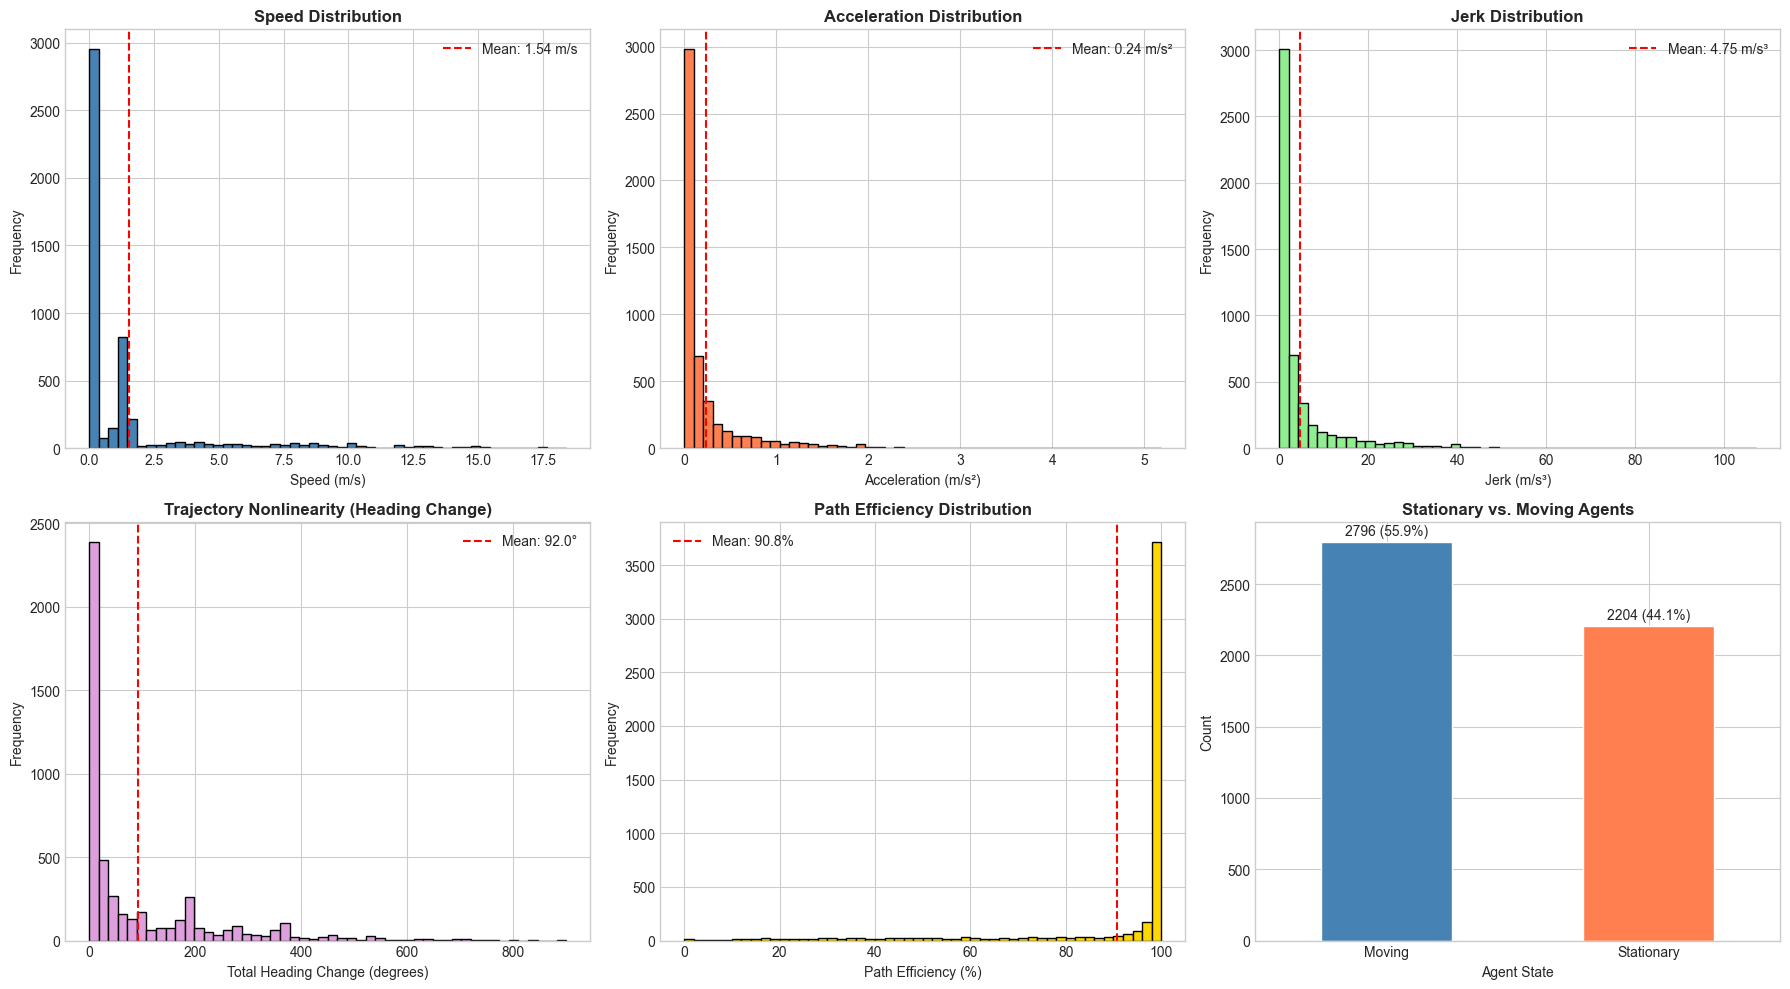


📊 Motion Dynamics Summary:
Speed:
  Mean: 1.54 m/s
  Median: 0.12 m/s
  Std: 3.09 m/s

Acceleration:
  Mean: 0.24 m/s²
  Median: 0.06 m/s²
  Std: 0.47 m/s²

Jerk:
  Mean: 4.75 m/s³
  Median: 1.13 m/s³

Trajectory Nonlinearity (Heading Change):
  Mean: 91.98°
  Median: 20.67°

Path Efficiency:
  Mean: 90.79%
  Median: 99.96%

Stationary Agents: 2796 (55.9%)


In [56]:
# Visualize motion dynamics
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# Speed distribution
ax = axes[0, 0]
motion_df['speed'].hist(bins=50, ax=ax, color='steelblue', edgecolor='black')
ax.set_title('Speed Distribution', fontsize=12, fontweight='bold')
ax.set_xlabel('Speed (m/s)')
ax.set_ylabel('Frequency')
ax.axvline(motion_df['speed'].mean(), color='red', linestyle='--',
           label=f'Mean: {motion_df["speed"].mean():.2f} m/s')
ax.legend()

# Acceleration distribution
ax = axes[0, 1]
motion_df['acceleration'].hist(bins=50, ax=ax, color='coral', edgecolor='black')
ax.set_title('Acceleration Distribution', fontsize=12, fontweight='bold')
ax.set_xlabel('Acceleration (m/s²)')
ax.set_ylabel('Frequency')
ax.axvline(motion_df['acceleration'].mean(), color='red', linestyle='--',
           label=f'Mean: {motion_df["acceleration"].mean():.2f} m/s²')
ax.legend()

# Jerk distribution
ax = axes[0, 2]
motion_df['jerk'].hist(bins=50, ax=ax, color='lightgreen', edgecolor='black')
ax.set_title('Jerk Distribution', fontsize=12, fontweight='bold')
ax.set_xlabel('Jerk (m/s³)')
ax.set_ylabel('Frequency')
ax.axvline(motion_df['jerk'].mean(), color='red', linestyle='--',
           label=f'Mean: {motion_df["jerk"].mean():.2f} m/s³')
ax.legend()

# Heading change distribution
ax = axes[1, 0]
motion_df['heading_change'].hist(bins=50, ax=ax, color='plum', edgecolor='black')
ax.set_title('Trajectory Nonlinearity (Heading Change)', fontsize=12, fontweight='bold')
ax.set_xlabel('Total Heading Change (degrees)')
ax.set_ylabel('Frequency')
ax.axvline(motion_df['heading_change'].mean(), color='red', linestyle='--',
           label=f'Mean: {motion_df["heading_change"].mean():.1f}°')
ax.legend()

# Path efficiency distribution
ax = axes[1, 1]
motion_df['path_efficiency'].hist(bins=50, ax=ax, color='gold', edgecolor='black')
ax.set_title('Path Efficiency Distribution', fontsize=12, fontweight='bold')
ax.set_xlabel('Path Efficiency (%)')
ax.set_ylabel('Frequency')
ax.axvline(motion_df['path_efficiency'].mean(), color='red', linestyle='--',
           label=f'Mean: {motion_df["path_efficiency"].mean():.1f}%')
ax.legend()

# Stationary vs moving
ax = axes[1, 2]
stationary_counts = motion_df['is_stationary'].value_counts()
stationary_counts.index = ['Moving', 'Stationary']
stationary_counts.plot(kind='bar', ax=ax, color=['steelblue', 'coral'])
ax.set_title('Stationary vs. Moving Agents', fontsize=12, fontweight='bold')
ax.set_xlabel('Agent State')
ax.set_ylabel('Count')
ax.tick_params(axis='x', rotation=0)
for i, v in enumerate(stationary_counts):
    ax.text(i, v + 50, f'{v} ({v/len(motion_df)*100:.1f}%)', ha='center')

plt.tight_layout()
plt.savefig('../results/evaluation/plots/characterization/motion_dynamics.png', dpi=300, bbox_inches='tight')
plt.show()

# Print statistics
print("\n📊 Motion Dynamics Summary:")
print("=" * 50)
print(f"Speed:")
print(f"  Mean: {motion_df['speed'].mean():.2f} m/s")
print(f"  Median: {motion_df['speed'].median():.2f} m/s")
print(f"  Std: {motion_df['speed'].std():.2f} m/s")
print(f"\nAcceleration:")
print(f"  Mean: {motion_df['acceleration'].mean():.2f} m/s²")
print(f"  Median: {motion_df['acceleration'].median():.2f} m/s²")
print(f"  Std: {motion_df['acceleration'].std():.2f} m/s²")
print(f"\nJerk:")
print(f"  Mean: {motion_df['jerk'].mean():.2f} m/s³")
print(f"  Median: {motion_df['jerk'].median():.2f} m/s³")
print(f"\nTrajectory Nonlinearity (Heading Change):")
print(f"  Mean: {motion_df['heading_change'].mean():.2f}°")
print(f"  Median: {motion_df['heading_change'].median():.2f}°")
print(f"\nPath Efficiency:")
print(f"  Mean: {motion_df['path_efficiency'].mean():.2f}%")
print(f"  Median: {motion_df['path_efficiency'].median():.2f}%")
print(f"\nStationary Agents: {motion_df['is_stationary'].sum()} ({motion_df['is_stationary'].sum()/len(motion_df)*100:.1f}%)")

## Step 2: Defining Meaningful Subsets

Create subsets for performance comparison based on dataset characteristics.

In [ ]:
# Combine all data for subset analysis
combined_df = pd.DataFrame({
    'agent_type': agent_types[:len(motion_df)],
    'num_neighbors': scene_df['num_neighbors'][:len(motion_df)],
    'agent_density_m2': scene_df['agent_density_m2'][:len(motion_df)],
    'speed': motion_df['speed'],
    'acceleration': motion_df['acceleration'],
    'heading_change': motion_df['heading_change'],
    'path_efficiency': motion_df['path_efficiency'],
    'is_stationary': motion_df['is_stationary'],
})

print(f"Combined dataset: {len(combined_df)} samples")

Combined dataset: 5000 samples


### 2.1 Density-Based Subsets

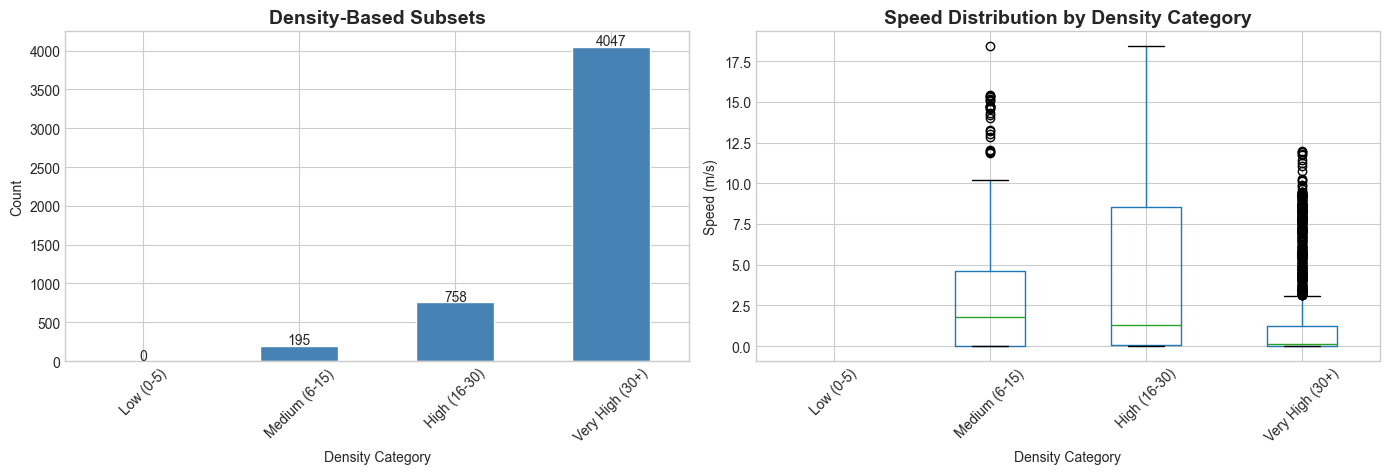


📊 Density-Based Subsets:
Low (0-5): 0 samples (0.0%)
Medium (6-15): 195 samples (3.9%)
High (16-30): 758 samples (15.2%)
Very High (30+): 4047 samples (80.9%)


In [58]:
# Define density categories
combined_df['density_category'] = pd.cut(
    combined_df['num_neighbors'],
    bins=[0, 5, 15, 30, 1000],
    labels=['Low (0-5)', 'Medium (6-15)', 'High (16-30)', 'Very High (30+)']
)

# Visualize density subsets
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Density distribution
ax = axes[0]
density_counts = combined_df['density_category'].value_counts().sort_index()
density_counts.plot(kind='bar', ax=ax, color='steelblue')
ax.set_title('Density-Based Subsets', fontsize=14, fontweight='bold')
ax.set_xlabel('Density Category')
ax.set_ylabel('Count')
ax.tick_params(axis='x', rotation=45)
for i, v in enumerate(density_counts):
    ax.text(i, v + 20, str(v), ha='center')

# Speed by density
ax = axes[1]
combined_df.boxplot(column='speed', by='density_category', ax=ax)
ax.set_title('Speed Distribution by Density Category', fontsize=14, fontweight='bold')
ax.set_xlabel('Density Category')
ax.set_ylabel('Speed (m/s)')
ax.tick_params(axis='x', rotation=45)
ax.get_figure().suptitle('')  # Remove default title

plt.tight_layout()
plt.savefig('../results/evaluation/plots/characterization/density_subsets.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n📊 Density-Based Subsets:")
print("=" * 50)
for category in density_counts.index:
    count = density_counts[category]
    pct = count / len(combined_df) * 100
    print(f"{category}: {count} samples ({pct:.1f}%)")

### 2.2 Motion-Based Subsets

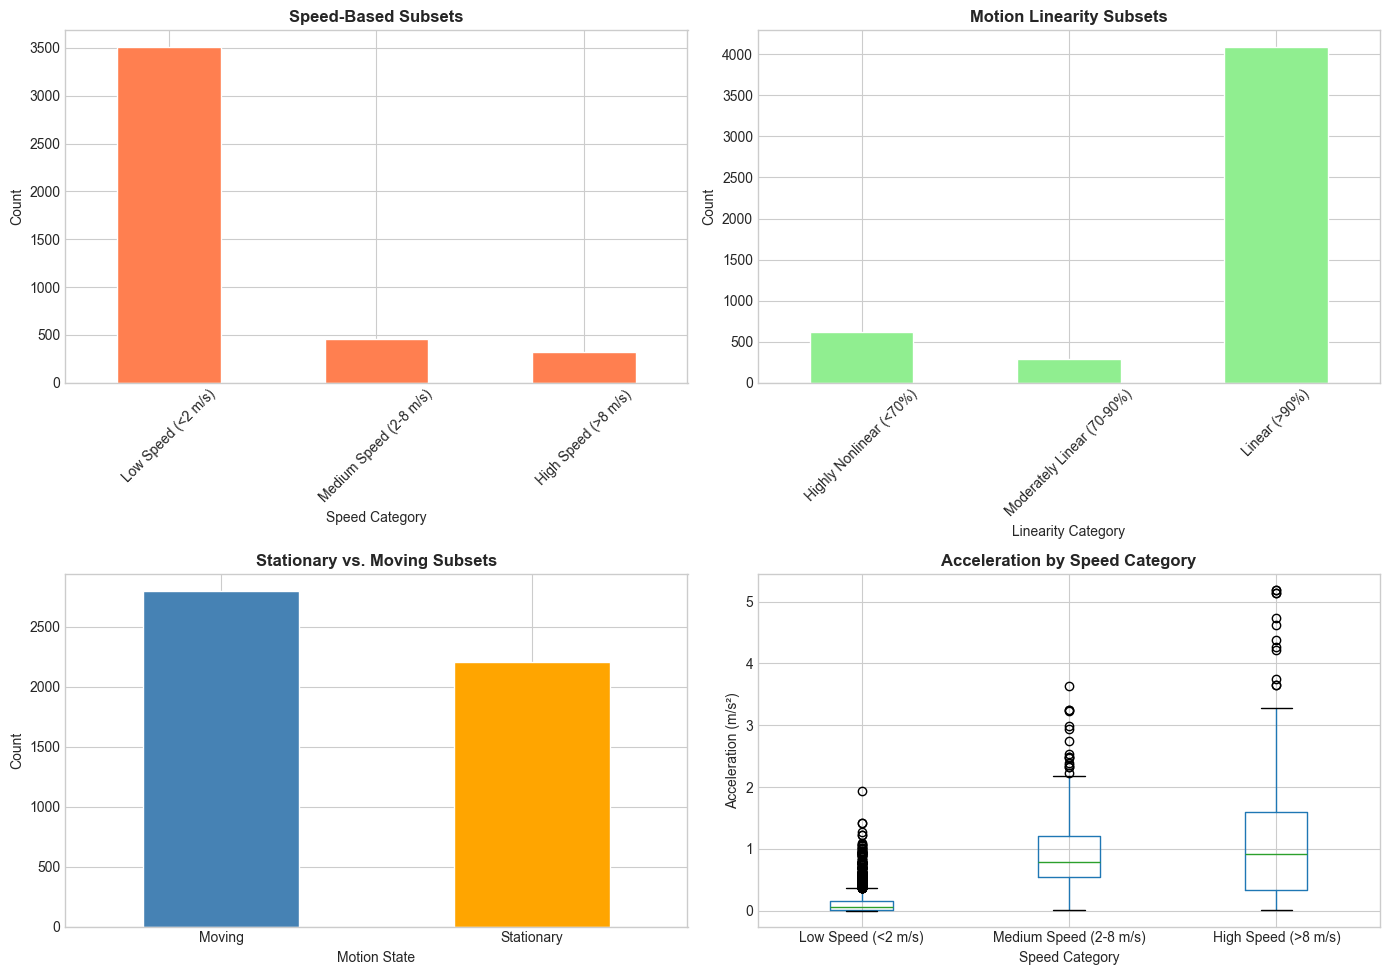


📊 Motion-Based Subsets:

Speed Categories:
  Low Speed (<2 m/s): 3508 (70.2%)
  Medium Speed (2-8 m/s): 462 (9.2%)
  High Speed (>8 m/s): 317 (6.3%)

Linearity Categories:
  Highly Nonlinear (<70%): 622 (12.4%)
  Moderately Linear (70-90%): 286 (5.7%)
  Linear (>90%): 4087 (81.7%)


In [59]:
# Define motion categories
combined_df['speed_category'] = pd.cut(
    combined_df['speed'],
    bins=[0, 2, 8, 100],
    labels=['Low Speed (<2 m/s)', 'Medium Speed (2-8 m/s)', 'High Speed (>8 m/s)']
)

combined_df['motion_linearity'] = pd.cut(
    combined_df['path_efficiency'],
    bins=[0, 70, 90, 100],
    labels=['Highly Nonlinear (<70%)', 'Moderately Linear (70-90%)', 'Linear (>90%)']
)

# Visualize motion subsets
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Speed categories
ax = axes[0, 0]
speed_counts = combined_df['speed_category'].value_counts().sort_index()
speed_counts.plot(kind='bar', ax=ax, color='coral')
ax.set_title('Speed-Based Subsets', fontsize=12, fontweight='bold')
ax.set_xlabel('Speed Category')
ax.set_ylabel('Count')
ax.tick_params(axis='x', rotation=45)

# Linearity categories
ax = axes[0, 1]
linearity_counts = combined_df['motion_linearity'].value_counts().sort_index()
linearity_counts.plot(kind='bar', ax=ax, color='lightgreen')
ax.set_title('Motion Linearity Subsets', fontsize=12, fontweight='bold')
ax.set_xlabel('Linearity Category')
ax.set_ylabel('Count')
ax.tick_params(axis='x', rotation=45)

# Stationary vs moving
ax = axes[1, 0]
stationary_counts = combined_df['is_stationary'].value_counts()
stationary_counts.index = ['Moving', 'Stationary']
stationary_counts.plot(kind='bar', ax=ax, color=['steelblue', 'orange'])
ax.set_title('Stationary vs. Moving Subsets', fontsize=12, fontweight='bold')
ax.set_xlabel('Motion State')
ax.set_ylabel('Count')
ax.tick_params(axis='x', rotation=0)

# Acceleration by speed category
ax = axes[1, 1]
combined_df.boxplot(column='acceleration', by='speed_category', ax=ax)
ax.set_title('Acceleration by Speed Category', fontsize=12, fontweight='bold')
ax.set_xlabel('Speed Category')
ax.set_ylabel('Acceleration (m/s²)')
plt.suptitle('')

plt.tight_layout()
plt.savefig('../results/evaluation/plots/characterization/motion_subsets.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n📊 Motion-Based Subsets:")
print("=" * 50)
print("\nSpeed Categories:")
for category in speed_counts.index:
    count = speed_counts[category]
    pct = count / len(combined_df) * 100
    print(f"  {category}: {count} ({pct:.1f}%)")

print("\nLinearity Categories:")
for category in linearity_counts.index:
    count = linearity_counts[category]
    pct = count / len(combined_df) * 100
    print(f"  {category}: {count} ({pct:.1f}%)")

### 2.3 Agent Type Subsets

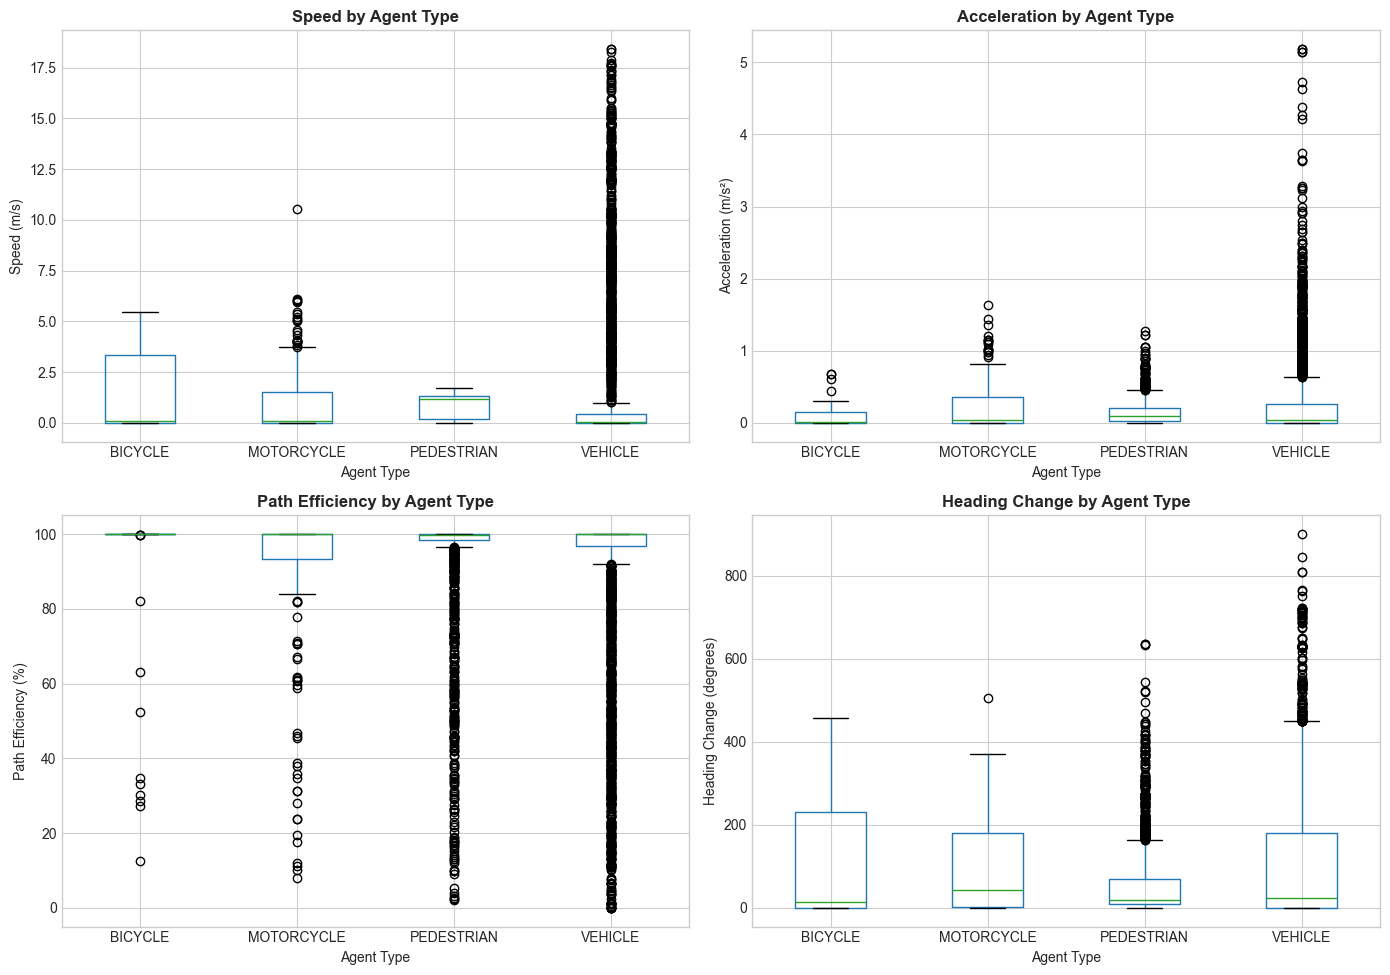


📊 Motion Statistics by Agent Type:

VEHICLE:
  Count: 3131
  Mean Speed: 1.88 m/s
  Mean Acceleration: 0.29 m/s²
  Mean Path Efficiency: 89.7%
  Mean Heading Change: 106.8°

PEDESTRIAN:
  Count: 1646
  Mean Speed: 0.94 m/s
  Mean Acceleration: 0.15 m/s²
  Mean Path Efficiency: 93.1%
  Mean Heading Change: 62.1°

MOTORCYCLE:
  Count: 172
  Mean Speed: 1.09 m/s
  Mean Acceleration: 0.24 m/s²
  Mean Path Efficiency: 88.5%
  Mean Heading Change: 99.0°

BICYCLE:
  Count: 51
  Mean Speed: 1.45 m/s
  Mean Acceleration: 0.11 m/s²
  Mean Path Efficiency: 89.5%
  Mean Heading Change: 120.4°


In [60]:
# Analyze motion characteristics by agent type
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Speed by agent type
ax = axes[0, 0]
combined_df.boxplot(column='speed', by='agent_type', ax=ax)
ax.set_title('Speed by Agent Type', fontsize=12, fontweight='bold')
ax.set_xlabel('Agent Type')
ax.set_ylabel('Speed (m/s)')
plt.suptitle('')

# Acceleration by agent type
ax = axes[0, 1]
combined_df.boxplot(column='acceleration', by='agent_type', ax=ax)
ax.set_title('Acceleration by Agent Type', fontsize=12, fontweight='bold')
ax.set_xlabel('Agent Type')
ax.set_ylabel('Acceleration (m/s²)')
plt.suptitle('')

# Path efficiency by agent type
ax = axes[1, 0]
combined_df.boxplot(column='path_efficiency', by='agent_type', ax=ax)
ax.set_title('Path Efficiency by Agent Type', fontsize=12, fontweight='bold')
ax.set_xlabel('Agent Type')
ax.set_ylabel('Path Efficiency (%)')
plt.suptitle('')

# Heading change by agent type
ax = axes[1, 1]
combined_df.boxplot(column='heading_change', by='agent_type', ax=ax)
ax.set_title('Heading Change by Agent Type', fontsize=12, fontweight='bold')
ax.set_xlabel('Agent Type')
ax.set_ylabel('Heading Change (degrees)')
plt.suptitle('')

plt.tight_layout()
plt.savefig('../results/evaluation/plots/characterization/agent_type_motion.png', dpi=300, bbox_inches='tight')
plt.show()

# Print statistics by agent type
print("\n📊 Motion Statistics by Agent Type:")
print("=" * 50)
for agent_type in combined_df['agent_type'].unique():
    subset = combined_df[combined_df['agent_type'] == agent_type]
    print(f"\n{agent_type}:")
    print(f"  Count: {len(subset)}")
    print(f"  Mean Speed: {subset['speed'].mean():.2f} m/s")
    print(f"  Mean Acceleration: {subset['acceleration'].mean():.2f} m/s²")
    print(f"  Mean Path Efficiency: {subset['path_efficiency'].mean():.1f}%")
    print(f"  Mean Heading Change: {subset['heading_change'].mean():.1f}°")

## Summary and Export

Save the characterized data and subset definitions for downstream analysis.

In [ ]:
# Save combined dataset with subset labels
output_path = Path('../data/processed')
output_path.mkdir(parents=True, exist_ok=True)

combined_df.to_csv(output_path / 'dataset_characteristics.csv', index=False)
print(f"✓ Dataset characteristics saved to: {output_path / 'dataset_characteristics.csv'}")

# Save summary statistics
summary_stats = {
    'total_samples': len(combined_df),
    'agent_types': combined_df['agent_type'].value_counts().to_dict(),
    'density_distribution': combined_df['density_category'].value_counts().to_dict(),
    'speed_distribution': combined_df['speed_category'].value_counts().to_dict(),
    'motion_stats': {
        'mean_speed': float(combined_df['speed'].mean()),
        'mean_acceleration': float(combined_df['acceleration'].mean()),
        'mean_heading_change': float(combined_df['heading_change'].mean()),
        'mean_path_efficiency': float(combined_df['path_efficiency'].mean()),
        'stationary_ratio': float(combined_df['is_stationary'].mean()),
    },
    'scene_stats': {
        'mean_neighbors': float(combined_df['num_neighbors'].mean()),
        'mean_agent_density_m2': float(combined_df['agent_density_m2'].mean()),
        'median_neighbors': float(combined_df['num_neighbors'].median()),
        'max_neighbors': float(combined_df['num_neighbors'].max()),
    }
}

import json
with open(output_path / 'summary_statistics.json', 'w') as f:
    json.dump(summary_stats, f, indent=2)

print(f"✓ Summary statistics saved to: {output_path / 'summary_statistics.json'}")

✓ Dataset characteristics saved to: ../data/processed/dataset_characteristics.csv
✓ Summary statistics saved to: ../data/processed/summary_statistics.json


## Key Findings Summary

In [ ]:
print("\n" + "="*70)
print("📊 DATASET CHARACTERIZATION SUMMARY")
print("="*70)

print(f"\n1. AGENT POPULATION:")
print(f"   • Total unique agents: {len(agent_names)}")
print(f"   • Total trajectories analyzed: {len(combined_df)}")
print(f"   • Dominant agent type: {combined_df['agent_type'].mode()[0]}")

print(f"\n2. SCENE CHARACTERISTICS:")
print(f"   • Average agent density: {combined_df['num_neighbors'].mean():.2f} neighbors")
print(f"   • Average agent density (per m²): {combined_df['agent_density_m2'].mean():.4f} agents/m²")
print(f"   • Median agent density: {combined_df['num_neighbors'].median():.2f} neighbors")
print(f"   • Max neighbors observed: {combined_df['num_neighbors'].max():.0f}")
print(f"   • High-density scenes (>15 neighbors): {(combined_df['num_neighbors'] > 15).mean()*100:.1f}%")

print(f"\n3. MOTION DYNAMICS:")
print(f"   • Mean speed: {combined_df['speed'].mean():.2f} m/s")
print(f"   • Stationary agents: {combined_df['is_stationary'].mean()*100:.1f}%")
print(f"   • Nonlinear trajectories: {(combined_df['path_efficiency'] < 90).mean()*100:.1f}%")
print(f"   • Mean heading change: {combined_df['heading_change'].mean():.1f}°")

print(f"\n4. RECOMMENDED SUBSETS FOR EVALUATION:")
print(f"   • Density: Low (0-3), Medium (4-10), High (10+) neighbors")
print(f"   • Speed: Low (<2), Medium (2-8), High (>8) m/s")
print(f"   • Motion: Stationary vs. Moving")
print(f"   • Trajectory: Linear vs. Nonlinear")
print(f"   • Agent Type: {', '.join(combined_df['agent_type'].unique())}")

print(f"\n5. TRAJECTRON++ CONSIDERATIONS:")
print(f"   • Social interactions relevant in {(combined_df['num_neighbors'] > 0).mean()*100:.1f}% of scenes")
print(f"   • High motion variability suggests importance of dynamic models")
print(f"   • Agent type heterogeneity requires type-specific modeling")

print("\n" + "="*70)
print("✓ Analysis complete. Proceed to feature importance or baseline modeling.")
print("="*70)


📊 DATASET CHARACTERIZATION SUMMARY

1. AGENT POPULATION:
   • Total unique agents: 400
   • Total trajectories analyzed: 5000
   • Dominant agent type: VEHICLE

2. SCENE CHARACTERISTICS:
   • Average agent density: 48.52 neighbors
   • Median agent density: 56.00 neighbors
   • Max neighbors observed: 73
   • High-density scenes (>15 neighbors): 96.1%

3. MOTION DYNAMICS:
   • Mean speed: 1.54 m/s
   • Stationary agents: 55.9%
   • Nonlinear trajectories: 18.3%
   • Mean heading change: 92.0°

4. RECOMMENDED SUBSETS FOR EVALUATION:
   • Density: Low (0-3), Medium (4-10), High (10+) neighbors
   • Speed: Low (<2), Medium (2-8), High (>8) m/s
   • Motion: Stationary vs. Moving
   • Trajectory: Linear vs. Nonlinear
   • Agent Type: VEHICLE, PEDESTRIAN, MOTORCYCLE, BICYCLE

5. TRAJECTRON++ CONSIDERATIONS:
   • Social interactions relevant in 100.0% of scenes
   • High motion variability suggests importance of dynamic models
   • Agent type heterogeneity requires type-specific modeling

✓ 